In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
import seaborn as sns
from tensorflow.keras.layers import Dropout
from keras.layers import Dense, Input
from keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [28]:
x,y = make_circles(n_samples=100, factor=0.5, noise=0.1, random_state=1)

<Axes: >

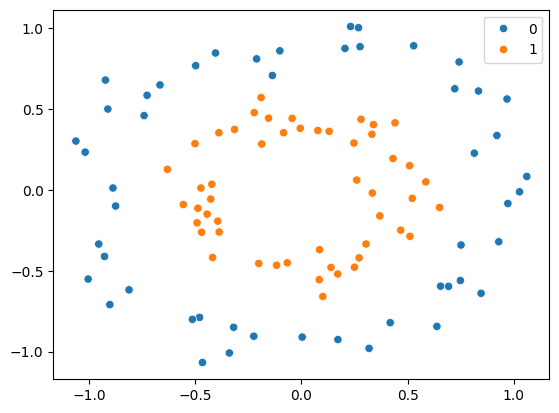

In [29]:
sns.scatterplot(x = x[:,0], y = x[:,1], hue=y)

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=1)

In [31]:
model = Sequential([
    Input(shape=(2,)),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [32]:
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

In [33]:
history = model.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test), verbose=0)

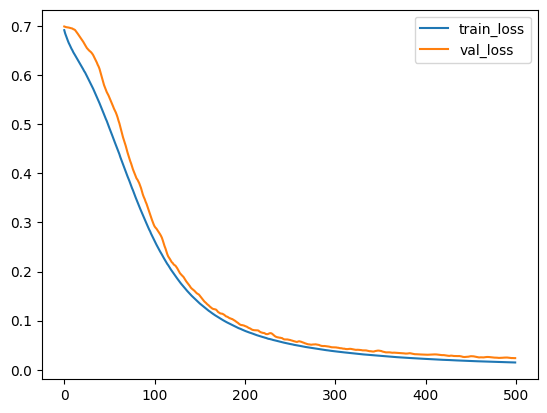

In [34]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 586us/step


<Axes: >

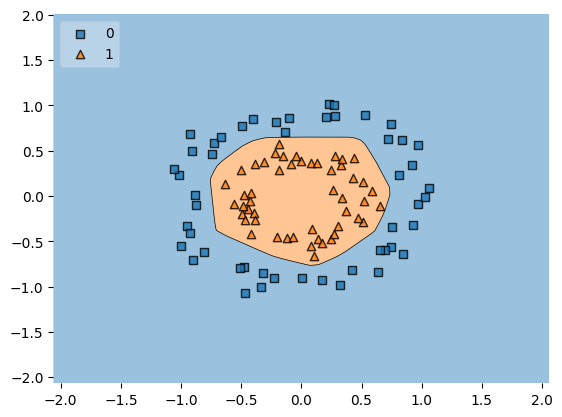

In [35]:
plot_decision_regions(x, y, clf=model, legend=2)

Now implementing Early stopping

In [36]:
model.compile(loss = 'binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

In [37]:
callback = EarlyStopping(
    monitor = 'val_loss',
    patience = 20,
    min_delta = 0.00001,
    verbose=1,
    baseline=None,
    restore_best_weights=False
)

In [38]:
history = model.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test), verbose=0, callbacks=callback)

Epoch 143: early stopping


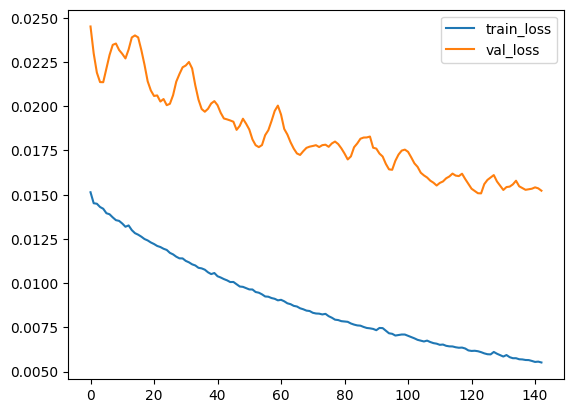

In [39]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()